# HTO correction angle — two-stage ablation suite

Companion to **`hto_correction_angles.ipynb`** (the one-stage model). This single notebook runs every two-stage experiment we need to (a) compare one-stage against a two-stage cropped-ROI pipeline and (b) substantiate the claim that **error cascades from ROI detection into landmark detection**. The Miniaci geometry and the full agreement battery are reused **verbatim** from the one-stage notebook, the sample pool and folds are shared image-for-image, and the only methodological variable is the model's input — ROI crops instead of the whole radiograph.

**Two knobs, one pipeline.** Stage-1 ROI boxes come from an *oracle* (the GT keypoints); **box jitter** perturbs them to simulate detector error, used both as a training-time robustness augmentation and as the controllable test-time error that produces the cascade. Stage-2 is either **3 region specialists** (`femoral_head`:1ch, `knee`:3, `ankle`:2) or **1 shared 6-channel model**.

**Experiments** (toggle at the top):

1. **Oracle ceiling, 5-fold CV** — 3 specialists vs 1 shared. Best-case two-stage; the architecture comparison with proper n.
2. **Cascade dose-response** — angle MAE vs ROI box error, for clean- and jitter-trained specialists. The mechanism, as a curve.
3. **Robustness CV** *(optional, heavy)* — clean- vs jitter-trained at one realistic box error, with pooled-CV n.
4. **Real YOLO operating point** *(optional, needs `ultralytics`)* — a trained detector anchored on the cascade curve; captures the missed/duplicate/wrong-leg failures jitter cannot.

> **Caveats.** Box jitter is a *conservative* detector surrogate — it models decentred crops, not hard detection failures, so it lower-bounds the real cascade (the YOLO arm shows the rest). `CROP_SIZE` packs more pixels per landmark than the full leg, so read any one-stage win alongside an input-resolution sweep. *Nothing here is executed in this authoring environment (no GPU / data / `CKD` / `ultralytics`); it is syntax- and `nbformat`-validated only. The YOLO cell is a template to verify against your data.*


## 1 · Setup, configuration & experiment switches

The one-stage notebook's setup (imports, paths, seed, `device`) followed by the two-stage + jitter config and the `RUN_*` flags. Defaults run the rigorous core — oracle CV (Exp 1) and the cascade curve (Exp 2); the heavier robustness CV and the YOLO arm are off. Paste your one-stage CV numbers into `ONE_STAGE_CV` to get the comparison row and the reference line on the cascade plot. `CROP_EPOCHS=600` is a starting point — raise for final numbers.


In [1]:
import os
import json
import random
import math
import sys
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn

sys.path.append(os.path.abspath("CKD"))
from models import (
    Conformer_tiny_patch16_keypoint_half_heatmap,
    Conformer_small_patch16_keypoint_half_heatmap,
    Conformer_small_patch32_keypoint_half_heatmap,
    Conformer_base_patch16_keypoint_half_heatmap,
)
from utils import extract_coordinates

DATA_DIR       = "/tf/data/hto/xrays"
COCO_JSON_PATH = os.path.join(DATA_DIR, "hto_annotations.json")
if not os.path.exists(COCO_JSON_PATH):
    COCO_JSON_PATH = "hto_annotations.json"

SEED           = 42
TARGET_SIZE    = 768
HEATMAP_SCALE  = 0.5
SIGMA          = 6.0
KP_EPOCHS      = 2_000
BATCH_SIZE     = 4
LEARNING_RATE  = 1e-4 * (HEATMAP_SCALE / 0.25)

MODEL_VARIANT   = "small_p16"
CHECKPOINT_PATH = "kfolds_models/best_model_global.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware device registered: {device}")

GLOBAL_KEYPOINT_NAMES = [
    "femur_head_lh", "knee_inner_lh", "ost_point_lh",
    "knee_outer_lh", "ankle_inner_lh", "ankle_outer_lh",
    "femur_head_rh", "knee_inner_rh", "ost_point_rh",
    "knee_outer_rh", "ankle_inner_rh", "ankle_outer_rh",
]

LANDMARK_COLORS = {
    "femur_head_lh":      "darkgreen",  "knee_inner_lh":    "darkblue",
    "ost_point_lh":       "darkred",    "knee_outer_lh":    "darkviolet",
    "ankle_inner_lh":     "darkorange", "ankle_outer_lh":   "teal",
    "fujisawa_lh":        "gold",       "ankle_c_lh":       "navy",
    "target_at_ankle_lh": "magenta",
    "femur_head_rh":      "lightgreen", "knee_inner_rh":    "lightblue",
    "ost_point_rh":       "lightcoral", "knee_outer_rh":    "plum",
    "ankle_inner_rh":     "sandybrown", "ankle_outer_rh":   "paleturquoise",
    "fujisawa_rh":        "khaki",      "ankle_c_rh":       "slategray",
    "target_at_ankle_rh": "violet",
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)


# ════════════════════════════════════════════════════════════════════════════
# TWO-STAGE EXPERIMENT SUITE — configuration
# Companion to hto_correction_angles.ipynb. Everything above is reused verbatim
# from the one-stage notebook (data, splits, metrics, geometry, agreement battery)
# so the only methodological variable is the model's INPUT: ROI crops instead of
# the whole radiograph. This notebook runs the full two-stage ablation:
#   - oracle-crop ceiling (perfect ROI), 3 specialists vs 1 shared model
#   - cascade dose-response: angle error vs ROI box error (jitter sweep)
#   - train-time robustness: clean-trained vs box-jitter-trained stage-2
#   - (optional) a real YOLO operating point anchored on the cascade curve
# ════════════════════════════════════════════════════════════════════════════

# ── stage-2 crop config ─────────────────────────────────────────────────────
CROP_SIZE          = 384       # letterbox size per ROI crop (drives the resolution confound)
CROP_HEATMAP_SCALE = 0.5
CROP_SIGMA         = 6.0
CROP_BATCH_SIZE    = 8
CROP_LR            = 1e-4 * (CROP_HEATMAP_SCALE / 0.25)
CROP_EPOCHS        = 600       # per-region crops converge faster than the 2000 full-image budget;
                               #   raise for final numbers, lower for a quick pass.
N_SPLITS           = 5
CROP_MARGIN_FRAC   = 0.35      # oracle-box padding as a fraction of the keypoint span
CROP_MIN_HALF_FRAC = 0.05      # min half-box (fraction of image WIDTH) — handles 1-point ROIs
CROP_CKPT_DIR      = "kfolds_models_crop"
os.makedirs(CROP_CKPT_DIR, exist_ok=True)

# Region -> ordered keypoint-type names (side-agnostic). Hemisphere slot offsets:
#   0 femur_head | 1 knee_inner | 2 ost_point | 3 knee_outer | 4 ankle_inner | 5 ankle_outer
HEMI_KP      = ["femur_head", "knee_inner", "ost_point", "knee_outer", "ankle_inner", "ankle_outer"]
KP_OFFSET    = {name: i for i, name in enumerate(HEMI_KP)}
HEMI_BASE    = {"L": 0, "R": 6}
REGIONS      = {"femoral_head": ["femur_head"],
                "knee":         ["knee_inner", "ost_point", "knee_outer"],
                "ankle":        ["ankle_inner", "ankle_outer"]}
REGION_ORDER = ["femoral_head", "knee", "ankle"]

# ── cascade / jitter config ─────────────────────────────────────────────────
# Box jitter = random translation (fraction of box size) + scale (±fraction). Used
# two ways: at TRAIN time as a robustness augmentation, and at TEST time as the
# controllable ROI-error knob that produces the cascade. Jitter is a CONSERVATIVE
# detector surrogate — it captures decentred-crop covariate shift but NOT missed /
# duplicate / wrong-leg detections, which only the real YOLO arm shows.
TRAIN_JITTER_LEVEL = 0.12      # jitter magnitude used when training the "robust" stage-2
JITTER_SWEEP       = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]   # test-time magnitudes for the curve
N_REPEAT           = 3         # random draws averaged per test jitter level (>0)
REALISTIC_JITTER   = 0.15      # single operating point for the optional robustness CV

# ── experiment switches ─────────────────────────────────────────────────────
RUN_CV        = True           # Exp 1: oracle 5-fold CV, 3 specialists vs 1 shared (rigorous ceiling)
RUN_SWEEP     = True           # Exp 2: cascade dose-response on the fixed split (clean vs robust 3)
RUN_ROBUST_CV = True           # Exp 3 (heavy): CV at one realistic jitter, clean vs robust 3
RUN_YOLO      = True           # Exp 4 (needs `ultralytics`): real-detector operating point

# Paste your one-stage results here (from hto_correction_angles.ipynb) for the final
# comparison table / cascade-plot reference line. Leave None to skip.
ONE_STAGE_CV   = None          # e.g. {"n":108,"mean":0.7,"median":0.5,"max":3.1,"within_tol_pct":92.0,"icc":0.98}
ONE_STAGE_TEST = None

RESULTS = {}                   # every experiment writes its outputs here
print(f"Config ready | CROP_SIZE={CROP_SIZE} CROP_EPOCHS={CROP_EPOCHS} | "
      f"RUN_CV={RUN_CV} RUN_SWEEP={RUN_SWEEP} RUN_ROBUST_CV={RUN_ROBUST_CV} RUN_YOLO={RUN_YOLO}")


/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/tf/notebooks/CKD/vision_transformer.py:370: UserWarning: Overwriting vit_small_patch16_224 in registry with vision_transformer.vit_small_patch16_224. This is because the name being registe

Hardware device registered: cuda
Config ready | CROP_SIZE=384 CROP_EPOCHS=600 | RUN_CV=True RUN_SWEEP=True RUN_ROBUST_CV=True RUN_YOLO=True


In [2]:
print(f"PyTorch version: {torch.__version__}")
gpu_available = torch.cuda.is_available()
print(f"GPU available: {gpu_available}")
if gpu_available:
    print(f"GPU device name: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.5.1+cu121
GPU available: True
GPU device name: NVIDIA H100 80GB HBM3


## 2 · Reused one-stage machinery (verbatim)

Image letterboxing/augmentation, the COCO keypoint dataset, losses/metrics, the Conformer factory, the Miniaci geometry, and the agreement battery — copied unchanged from the one-stage notebook so the crop pipeline is scored by exactly the same code.


In [3]:
def preprocess_global_image(img, target_size=512):
    """Letterbox-resize *img* to a square canvas of *target_size* pixels."""
    orig_w, orig_h = img.size
    scale   = min(target_size / orig_w, target_size / orig_h)
    new_w   = int(orig_w * scale)
    new_h   = int(orig_h * scale)
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    pad_left = (target_size - new_w) // 2
    pad_top  = (target_size - new_h) // 2
    final_img = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    final_img.paste(resized, (pad_left, pad_top))
    return final_img, scale, (pad_left, pad_top)


def apply_augmentation(pil_img, final_kps):
    """Stochastic photometric and geometric augmentations.
    Returns (augmented_img, updated_kps)."""
    import torchvision.transforms.functional as TF
    import cv2

    img = pil_img
    kps = [list(kp) for kp in final_kps]
    W, H = img.size

    if random.random() < 0.6:
        img = TF.adjust_brightness(img, 1.0 + random.uniform(-0.25, 0.25))
    if random.random() < 0.6:
        img = TF.adjust_contrast(img, 1.0 + random.uniform(-0.25, 0.25))

    if random.random() < 0.4:
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(3, 12), arr.shape)
        arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img   = Image.fromarray(arr)

    if random.random() < 0.5:
        gamma = random.uniform(0.7, 1.4)
        arr   = np.array(img, dtype=np.float32) / 255.0
        img   = Image.fromarray((np.power(arr, gamma) * 255).astype(np.uint8))

    if random.random() < 0.4:
        arr       = np.array(img)
        clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        processed = clahe.apply(arr[:, :, 0])
        img       = Image.fromarray(np.stack([processed] * 3, axis=2))

    if random.random() < 0.3:
        img = TF.adjust_sharpness(img, random.uniform(0.5, 2.0))

    if random.random() < 0.5:
        angle    = random.uniform(-10, 10)
        img      = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
        cx, cy   = W / 2.0, H / 2.0
        rad      = math.radians(-angle)
        cos_a, sin_a = math.cos(rad), math.sin(rad)
        for kp in kps:
            if kp[0] < 0: continue
            dx, dy = kp[0] - cx, kp[1] - cy
            kp[0]  = cos_a * dx - sin_a * dy + cx
            kp[1]  = sin_a * dx + cos_a * dy + cy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        shift_y = random.randint(-15, 15)
        img = TF.affine(img, angle=0, translate=(0, shift_y), scale=1.0, shear=0)
        for kp in kps:
            if kp[0] < 0: continue
            kp[1] += shift_y
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    if random.random() < 0.3:
        sf    = random.uniform(0.90, 1.10)
        new_w = int(W * sf); new_h = int(H * sf)
        img   = TF.resize(img, [new_h, new_w])
        if sf < 1.0:
            pl, pt = (W - new_w) // 2, (H - new_h) // 2
            padded = Image.new("RGB", (W, H), (0, 0, 0))
            padded.paste(img, (pl, pt))
            img = padded; ox, oy = pl, pt
        else:
            cl, ct = (new_w - W) // 2, (new_h - H) // 2
            img = TF.crop(img, ct, cl, H, W); ox, oy = -cl, -ct
        for kp in kps:
            if kp[0] < 0: continue
            kp[0] = kp[0] * sf + ox; kp[1] = kp[1] * sf + oy
            if not (0 <= kp[0] < W and 0 <= kp[1] < H):
                kp[0], kp[1] = -1.0, -1.0

    return img, kps


In [4]:
def _rep_x(ann):
    """Representative x-coordinate for hemisphere assignment.
 
    Uses the mean of all visible keypoint x-values so that the decision is
    driven by where the actual anatomy sits, not by where the annotator drew
    the bounding box.  Falls back to the bbox centre only when every keypoint
    is (0, 0, 0) (i.e. the annotation box exists but contains no points yet).
    """
    kps = ann.get("keypoints", [])
    xs  = [kps[i] for i in range(0, len(kps), 3) if kps[i] > 0]
    if xs:
        return sum(xs) / len(xs)
    bbox = ann.get("bbox", [0, 0, 0, 0])
    return bbox[0] + bbox[2] / 2
 
 
# ── dataset ───────────────────────────────────────────────────────────────────
 
class GlobalRadiographKeypointDataset(Dataset):
    """COCO-style dataset for global 12-keypoint detection on long-leg radiographs.
 
    Hemisphere assignment
    ---------------------
    Annotations are grouped by category.  For each category, the annotation
    with the *smaller* representative x goes to the left hemisphere (base=0,
    slots 0-5) and the one with the *larger* representative x goes to the
    right hemisphere (base=6, slots 11).  This is a purely relative decision
    — no fixed image-midpoint threshold is involved — so it is robust to
    bounding boxes that straddle the image centre-line (the root cause of the
    misassignment in 23_0.png / 20_0.png with the old loader).
 
    The fallback to the image midpoint is kept only for categories that have
    exactly one annotation, where relative ordering is impossible.
 
    Parameters
    ----------
    indices : list[int] or None
        Explicit sample positions into the shuffled pool.  When given,
        split_ratios are ignored — used by the k-fold cross-validation loop.
    """
 
    def __init__(
        self,
        coco_json_path,
        split="train",
        split_ratios=(0.8, 0.1, 0.1),
        target_size=512,
        heatmap_scale=0.25,
        sigma=2.0,
        seed=42,
        indices=None,
    ):
        super().__init__()
        self.target_size   = target_size
        self.heatmap_scale = heatmap_scale
        self.sigma         = sigma
        self.num_keypoints = 12
        self.split         = split
 
        with open(coco_json_path, "r") as f:
            coco_data = json.load(f)
 
        images_info = {img["id"]: img for img in coco_data.get("images", [])}
 
        # ── group annotations by image ────────────────────────────────────
        anns_by_img = {}
        for ann in coco_data.get("annotations", []):
            anns_by_img.setdefault(ann.get("image_id"), []).append(ann)
 
        # ── build valid samples ───────────────────────────────────────────
        valid_samples = []
 
        for img_id, anns in anns_by_img.items():
            if img_id not in images_info:
                continue
 
            img_info = images_info[img_id]
            img_w    = img_info.get("width", 2860)
 
            # ── hemisphere assignment: relative, not midpoint-based ───────
            # Group annotations for this image by category, then assign
            # left / right by sorting on representative x.
            by_cat = {}
            for ann in anns:
                by_cat.setdefault(ann.get("category_id"), []).append(ann)
 
            kps_flat = [-1.0, -1.0, 0] * 12
            has_kp   = False
 
            for cat_id, cat_anns in by_cat.items():
                sorted_anns = sorted(cat_anns, key=_rep_x)
 
                if len(sorted_anns) == 2:
                    # Common case: one annotation per leg.
                    # Smaller x → left hemisphere, larger x → right hemisphere.
                    assignments = [(sorted_anns[0], 0), (sorted_anns[1], 6)]
 
                elif len(sorted_anns) == 1:
                    # Only one leg annotated for this category.
                    # Fall back to absolute image midpoint.
                    x    = _rep_x(sorted_anns[0])
                    base = 0 if x < img_w / 2.0 else 6
                    assignments = [(sorted_anns[0], base)]
 
                else:
                    # More than two annotations: take the leftmost and
                    # rightmost and discard the rest.
                    assignments = [(sorted_anns[0], 0), (sorted_anns[-1], 6)]
 
                for ann, base in assignments:
                    kps = ann.get("keypoints", [])
                    if cat_id == 1 and len(kps) >= 3:
                        kps_flat[base * 3:(base + 1) * 3] = [
                            kps[0], kps[1], 2 if kps[0] > 0 else 0
                        ]
                        if kps[0] > 0:
                            has_kp = True
 
                    elif cat_id == 2 and len(kps) >= 9:
                        for k in range(3):
                            s = base + 1 + k
                            kps_flat[s * 3:(s + 1) * 3] = [
                                kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]
                            ]
                            if kps[k * 3 + 2] > 0:
                                has_kp = True
 
                    elif cat_id == 3 and len(kps) >= 6:
                        for k in range(2):
                            s = base + 4 + k
                            kps_flat[s * 3:(s + 1) * 3] = [
                                kps[k * 3], kps[k * 3 + 1], kps[k * 3 + 2]
                            ]
                            if kps[k * 3 + 2] > 0:
                                has_kp = True
 
            if has_kp:
                filename = img_info.get("file_name")
                img_dir  = os.path.dirname(coco_json_path) or "."
                if not os.path.exists(os.path.join(img_dir, filename)):
                    alt = os.path.join("/tf/data/hto/xrays", os.path.basename(filename))
                    if os.path.exists(alt):
                        img_dir = "/tf/data/hto/xrays"
                valid_samples.append({
                    "img_path":  os.path.join(img_dir, filename),
                    "orig_size": (img_w, img_info.get("height", 8000)),
                    "keypoints": kps_flat,
                })
 
        # ── deterministic shuffle, then split ─────────────────────────────
        valid_samples.sort(key=lambda x: x["img_path"])
        random.seed(seed)
        random.shuffle(valid_samples)
 
        if indices is not None:
            self.samples = [valid_samples[i] for i in indices]
        else:
            n         = len(valid_samples)
            train_end = int(n * split_ratios[0])
            val_end   = train_end + int(n * split_ratios[1])
            self.samples = {
                "train": valid_samples[:train_end],
                "val":   valid_samples[train_end:val_end],
                "test":  valid_samples[val_end:],
            }.get(split, valid_samples)   # "all" (or any unknown key) → full list
 
    # ── protocol ──────────────────────────────────────────────────────────────
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        sample = self.samples[idx]
 
        try:
            img = Image.open(sample["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", sample["orig_size"], color=(128, 128, 128))
 
        processed_img, scale, padding = preprocess_global_image(img, self.target_size)
 
        # ── map keypoints into the padded canvas ──────────────────────────
        final_kps, kp_visibility = [], []
        for i in range(self.num_keypoints):
            kp_x = sample["keypoints"][i * 3]
            kp_y = sample["keypoints"][i * 3 + 1]
            kp_v = sample["keypoints"][i * 3 + 2]
            if kp_v > 0 and kp_x >= 0 and kp_y >= 0:
                final_kps.append([kp_x * scale + padding[0],
                                   kp_y * scale + padding[1]])
                kp_visibility.append(1.0)
            else:
                final_kps.append([-1.0, -1.0])
                kp_visibility.append(0.0)
 
        # ── augmentation (training only) ──────────────────────────────────
        if self.split == "train":
            processed_img, final_kps = apply_augmentation(processed_img, final_kps)
            kp_visibility = [
                1.0 if final_kps[i][0] >= 0 else 0.0
                for i in range(self.num_keypoints)
            ]
 
        # ── normalise image ───────────────────────────────────────────────
        img_tensor = (
            torch.from_numpy(np.array(processed_img))
            .permute(2, 0, 1)
            .float()
            / 255.0
        )
        img_tensor = (
            img_tensor - torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        ) / torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
 
        # ── build Gaussian heatmap targets ────────────────────────────────
        hm_size = int(self.target_size * self.heatmap_scale)
        heatmap = np.zeros((self.num_keypoints, hm_size, hm_size), dtype=np.float32)
        x_grid  = np.arange(0, hm_size, 1, np.float32)
        y_grid  = np.arange(0, hm_size, 1, np.float32)[:, np.newaxis]
 
        for i in range(self.num_keypoints):
            if sample["keypoints"][i * 3 + 2] > 0 and final_kps[i][0] >= 0:
                hx = final_kps[i][0] * self.heatmap_scale
                hy = final_kps[i][1] * self.heatmap_scale
                heatmap[i] = np.exp(
                    -((x_grid - hx) ** 2 + (y_grid - hy) ** 2)
                    / (2 * self.sigma ** 2)
                )
 
        return {
            "image":    img_tensor,
            "heatmap":  torch.from_numpy(heatmap),
            "keypoint": torch.tensor(final_kps, dtype=torch.float32),
            "visibility": torch.tensor(kp_visibility, dtype=torch.float32),
            "img_path": sample["img_path"],
            "orig_size": torch.tensor(sample["orig_size"]),
        }


In [5]:
def masked_heatmap_loss(pred_hms, target_hms, visibility):
    """Per-channel MSE loss masked to visible keypoints."""
    mask        = visibility.unsqueeze(-1).unsqueeze(-1)
    masked_diff = (pred_hms - target_hms) ** 2 * mask
    H, W        = pred_hms.shape[-2], pred_hms.shape[-1]
    return masked_diff.sum() / (mask.sum().clamp(min=1) * H * W)


def calculate_mse(preds, gts):
    """Mean Squared Error (px\u00b2) over all valid keypoints."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    return torch.mean(torch.sum((preds - gts) ** 2, dim=-1)[valid_mask]).item()


def calculate_pck(preds, gts, threshold=0.05, normalize_by=512):
    """Percentage of Correct Keypoints at *threshold* \u00d7 *normalize_by* px."""
    valid_mask = gts[..., 0] >= 0
    if not torch.any(valid_mask): return 0.0
    correct = torch.norm(preds - gts, dim=-1) < (threshold * normalize_by)
    return torch.mean(correct[valid_mask].float()).item()


PCK_THRESHOLDS = [0.005, 0.01, 0.02, 0.05]


In [6]:
_model_map = {
    "tiny":      Conformer_tiny_patch16_keypoint_half_heatmap,
    "small_p16": Conformer_small_patch16_keypoint_half_heatmap,
    "small_p32": Conformer_small_patch32_keypoint_half_heatmap,
    "base":      Conformer_base_patch16_keypoint_half_heatmap,
}


In [7]:
def map_global_to_orig(kp_final, orig_size, target_size=512):
    """Invert the letterbox transform back to original image coordinates."""
    orig_w, orig_h = orig_size
    scale    = min(target_size / orig_w, target_size / orig_h)
    pad_left = (target_size - int(orig_w * scale)) // 2
    pad_top  = (target_size - int(orig_h * scale)) // 2
    return np.array([(kp_final[0] - pad_left) / scale,
                     (kp_final[1] - pad_top)  / scale])


def calculate_intersection(p1, p2, target_y):
    """X-coordinate where line (p1 → p2) crosses y = *target_y*."""
    if p2[0] == p1[0]: return p1[0]
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    if m == 0:
        return p1[0] if abs(target_y - p1[1]) < 1e-9 else float("nan")
    return (target_y - p1[1]) / m + p1[0]


def evaluate_side_geometry(points):
    """Compute the Miniaci correction angle Alpha for one leg hemisphere.

    Parameters
    ----------
    points : dict with keys femur_head, knee_inner, ost_point,
             knee_outer, ankle_inner, ankle_outer (2-element arrays)

    Returns
    -------
    alpha, fujisawa, ankle_c, target_at_ankle
    """
    ankle_c  = (points["ankle_inner"] + points["ankle_outer"]) / 2.0
    fujisawa = points["knee_inner"] + 0.625 * (points["knee_outer"] - points["knee_inner"])

    tx              = calculate_intersection(points["femur_head"], fujisawa, ankle_c[1])
    target_at_ankle = np.array([tx, ankle_c[1]])

    v_orig   = ankle_c         - points["ost_point"]
    v_target = target_at_ankle - points["ost_point"]
    raw      = abs(math.atan2(v_orig[1], v_orig[0]) - math.atan2(v_target[1], v_target[0]))
    alpha    = min(raw, 2 * math.pi - raw) * 180.0 / math.pi
    return alpha, fujisawa, ankle_c, target_at_ankle


_SIDE_KEYS = ["femur_head", "knee_inner", "ost_point",
              "knee_outer", "ankle_inner", "ankle_outer"]


def evaluate_fold_angles(model, v_loader, dev):
    """Run inference on *v_loader* and return a dict of correction-angle
    error statistics across all valid hemisphere cases:

        mae  – mean absolute error (degrees)
        std  – standard deviation of absolute errors (degrees)
        max  – maximum absolute error (degrees)
        n    – number of valid hemisphere cases evaluated

    Returns None if no valid hemisphere pairs are found.
    """
    model.eval()
    abs_errors = []
    gt_list, pred_list = [], []

    with torch.no_grad():
        for batch in v_loader:
            imgs         = batch["image"].to(dev)
            pred_hms     = torch.sigmoid(model(imgs))
            coords_batch = extract_coordinates(
                pred_hms.cpu(), scale_factor=1.0 / HEATMAP_SCALE
            ).numpy()
            gts_batch  = batch["keypoint"].numpy()
            orig_sizes = batch["orig_size"].numpy()

            for b in range(len(imgs)):
                orig_shape = orig_sizes[b]
                pred_c     = coords_batch[b]
                gt_c       = gts_batch[b]

                for base in [0, 6]:   # left hemisphere, right hemisphere
                    pts_gt, pts_pred = {}, {}
                    for k_off, name in enumerate(_SIDE_KEYS):
                        slot = base + k_off
                        if gt_c[slot][0] >= 0:
                            pts_gt[name]   = map_global_to_orig(gt_c[slot],   orig_shape, TARGET_SIZE)
                            pts_pred[name] = map_global_to_orig(pred_c[slot], orig_shape, TARGET_SIZE)

                    if (all(k in pts_gt   for k in _SIDE_KEYS) and
                            all(k in pts_pred for k in _SIDE_KEYS)):
                        gt_alpha,   *_ = evaluate_side_geometry(pts_gt)
                        pred_alpha, *_ = evaluate_side_geometry(pts_pred)
                        abs_errors.append(abs(pred_alpha - gt_alpha))
                        gt_list.append(float(gt_alpha)); pred_list.append(float(pred_alpha))

    if not abs_errors:
        return None
    arr = np.array(abs_errors)
    return {"mae": float(arr.mean()),
            "std": float(arr.std()),
            "max": float(arr.max()),
            "n":   len(arr),
            "gt":  gt_list,
            "pred": pred_list}


In [8]:
# ============================================================================
# Correction-angle agreement statistics  (ports compute_stats.py into the
# notebook so the standalone scripts are no longer needed). CPU-only.
#
# Given paired arrays of ground-truth and predicted correction angles (one
# value per limb hemisphere), angle_agreement_report() prints and returns the
# full battery: mean / median / std / min / max absolute error, RMSE, % within
# the clinical tolerance, ICC(2,1) with 95% CI, Pearson r, and Bland-Altman
# bias + 95% limits of agreement.
# ============================================================================
import pandas as pd

CLINICAL_TOLERANCE_DEG = 1.63          # Jiang et al. correction-angle tolerance


def icc21_manual(ratings):
    """ICC(2,1): two-way random, absolute agreement, single measurement.
    ratings: array (n_targets, k_raters). Point estimate (Shrout & Fleiss 1979)."""
    ratings = np.asarray(ratings, dtype=float)
    n, k = ratings.shape
    grand     = ratings.mean()
    row_means = ratings.mean(axis=1, keepdims=True)
    col_means = ratings.mean(axis=0, keepdims=True)
    ss_total = ((ratings - grand) ** 2).sum()
    ss_row   = k * ((row_means - grand) ** 2).sum()
    ss_col   = n * ((col_means - grand) ** 2).sum()
    ss_err   = ss_total - ss_row - ss_col
    ms_row = ss_row / (n - 1)
    ms_col = ss_col / (k - 1)
    ms_err = ss_err / ((n - 1) * (k - 1))
    denom = ms_row + (k - 1) * ms_err + (k / n) * (ms_col - ms_err)
    return float((ms_row - ms_err) / denom)


def compute_icc(gt, pred):
    """(icc, ci_low, ci_high, method). pingouin gives the exact 95% CI if
    installed; otherwise a manual ICC(2,1) point estimate (no CI). The two
    'raters' are the mean-observer GT and the automatic method."""
    gt   = np.asarray(gt, dtype=float)
    pred = np.asarray(pred, dtype=float)
    n = len(gt)
    try:
        import pingouin as pg
        long = pd.DataFrame({
            "target": list(range(n)) * 2,
            "rater":  ["mean_observer"] * n + ["auto"] * n,
            "angle":  np.concatenate([gt, pred]),
        })
        res = pg.intraclass_corr(data=long, targets="target", raters="rater", ratings="angle")
        row = res.loc[res["Type"].isin(["ICC2", "ICC(A,1)"])].iloc[0]
        ci_col = "CI95%" if "CI95%" in res.columns else "CI95"
        ci = row[ci_col]
        return float(row["ICC"]), float(ci[0]), float(ci[1]), "pingouin ICC(2,1)"
    except ImportError:
        return (icc21_manual(np.column_stack([gt, pred])), np.nan, np.nan,
                "manual ICC(2,1) -- pip install pingouin for the 95% CI")


def angle_agreement_report(gt, pred, tolerance=CLINICAL_TOLERANCE_DEG, label="", show_reference=True):
    """Print and return the full correction-angle agreement battery for paired
    (ground-truth, predicted) angles in degrees."""
    gt   = np.asarray(gt, dtype=float)
    pred = np.asarray(pred, dtype=float)
    diff    = pred - gt                 # signed error (Bland-Altman)
    abs_err = np.abs(diff)             # absolute error (matches predecessor)

    icc, lo, hi, method = compute_icc(gt, pred)
    bias    = diff.mean()
    sd_diff = diff.std(ddof=1)
    loa_low, loa_high = bias - 1.96 * sd_diff, bias + 1.96 * sd_diff
    pearson = np.corrcoef(gt, pred)[0, 1] if len(gt) > 1 else float("nan")
    within  = 100.0 * np.mean(abs_err <= tolerance)
    rmse    = float(np.sqrt(np.mean(diff ** 2)))
    ci_str  = "" if np.isnan(lo) else f" ({lo:.3f}-{hi:.3f} 95% CI)"

    print("=" * 64)
    print(f"  {label}   (n = {len(gt)} limb hemispheres)")
    print("=" * 64)
    print("Absolute correction-angle error (degrees)")
    print(f"  mean    : {abs_err.mean():.4f}")
    print(f"  median  : {np.median(abs_err):.4f}")
    print(f"  std     : {abs_err.std(ddof=1):.4f}")
    print(f"  min     : {abs_err.min():.4f}")
    print(f"  max     : {abs_err.max():.4f}")
    print(f"  RMSE    : {rmse:.4f}")
    print(f"  within +/-{tolerance:.2f} deg : {within:.1f}%")
    print("\nAgreement")
    print(f"  ICC(2,1) : {icc:.3f}{ci_str}   [{method}]")
    print(f"  Pearson r: {pearson:.4f}")
    print("\nBland-Altman (predicted - GT)")
    print(f"  bias (mean diff)       : {bias:+.4f}")
    print(f"  95% limits of agreement: [{loa_low:+.4f}, {loa_high:+.4f}]")
    if show_reference:
        print("\nReference -- Przystalski et al. 2023 (MR vs FAM, same protocol):")
        print("  mean 0.5 | median 0.3 | max 2.76 | ICC 0.99 (0.98-0.99)")
    print("=" * 64 + "\n")

    return {"label": label, "n": int(len(gt)),
            "mean": float(abs_err.mean()), "median": float(np.median(abs_err)),
            "std": float(abs_err.std(ddof=1)), "min": float(abs_err.min()),
            "max": float(abs_err.max()), "rmse": rmse, "within_tol_pct": float(within),
            "icc": float(icc), "icc_lo": float(lo), "icc_hi": float(hi),
            "ba_bias": float(bias), "ba_loa_low": float(loa_low), "ba_loa_high": float(loa_high),
            "pearson": float(pearson)}


## 3 · Crop + jitter machinery, trainers, and the CV runner

The new code: oracle `region_box`, `jitter_box` (the detector surrogate), the invertible crop↔letterbox transform, `CropKeypointDataset` (serves both architectures; `box_jitter` enables robust training), the heatmap-only `train_crop_model`, the box-source factories (oracle / jitter / YOLO), `evaluate_crop_pipeline` (assembles each leg's six points and scores the angle), the `train_specialists` / `train_shared` trainers, and `run_cv` (per-fold training on the shared folds, pooled out-of-fold scoring).


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# Oracle ROI cropping  +  box jitter  +  crop dataset  +  crop training loop
# ----------------------------------------------------------------------------
# The "stage-1 detector" is an ORACLE box derived from the GT keypoints; box
# jitter perturbs that box to simulate detector error (at train and/or test).
# Crops come from the SAME canonical pool as the one-stage notebook, so folds
# and the 80/10/10 split line up image-for-image (paired comparison).
# ════════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import KFold


def build_sample_pool():
    """Canonical, deterministically-shuffled per-image samples
    {img_path, orig_size, keypoints[12*3] in ORIGINAL coords}. Reuses the
    one-stage parser, so identity & order match the global notebook exactly."""
    pool = GlobalRadiographKeypointDataset(
        COCO_JSON_PATH, split="all",
        target_size=TARGET_SIZE, heatmap_scale=HEATMAP_SCALE, sigma=SIGMA, seed=SEED)
    return pool.samples


def region_box(kps_flat, side, region, orig_size,
               margin_frac=CROP_MARGIN_FRAC, min_half_frac=CROP_MIN_HALF_FRAC):
    """Oracle ROI box (x0,y0,x1,y1) from a region's visible GT keypoints + margin.
    None if the region has no visible keypoint."""
    W, H  = float(orig_size[0]), float(orig_size[1])
    slots = [HEMI_BASE[side] + KP_OFFSET[n] for n in REGIONS[region]]
    pts   = [(kps_flat[s * 3], kps_flat[s * 3 + 1]) for s in slots
             if kps_flat[s * 3 + 2] > 0 and kps_flat[s * 3] >= 0]
    if not pts:
        return None
    xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
    x0, x1 = min(xs), max(xs); y0, y1 = min(ys), max(ys)
    mx = max(margin_frac * (x1 - x0), min_half_frac * W)
    my = max(margin_frac * (y1 - y0), min_half_frac * W)
    return (max(0.0, x0 - mx), max(0.0, y0 - my), min(W, x1 + mx), min(H, y1 + my))


def jitter_box(box, orig_size, trans_frac, scale_frac, rng):
    """Perturb *box* by random translation (fraction of box size) and scale (±frac).
    Simulates detector localisation error. Clipped to the image, kept non-degenerate."""
    x0, y0, x1, y1 = box
    w, h   = x1 - x0, y1 - y0
    cx, cy = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
    sw = w * (1.0 + rng.uniform(-scale_frac, scale_frac))
    sh = h * (1.0 + rng.uniform(-scale_frac, scale_frac))
    cx += rng.uniform(-trans_frac, trans_frac) * w
    cy += rng.uniform(-trans_frac, trans_frac) * h
    W, H = float(orig_size[0]), float(orig_size[1])
    nx0 = min(max(0.0, cx - sw / 2), W - 1); ny0 = min(max(0.0, cy - sh / 2), H - 1)
    nx1 = max(min(W, cx + sw / 2), nx0 + 1); ny1 = max(min(H, cy + sh / 2), ny0 + 1)
    return (nx0, ny0, nx1, ny1)


def crop_and_letterbox(img_pil, box, crop_size=CROP_SIZE):
    """Crop to integer *box* and letterbox to a square. Returns (pil, meta) where
    meta inverts back to ORIGINAL coords."""
    x0, y0, x1, y1 = (int(round(v)) for v in box)
    x1 = max(x1, x0 + 1); y1 = max(y1, y0 + 1)
    crop = img_pil.crop((x0, y0, x1, y1))
    lb, scale, (pl, pt) = preprocess_global_image(crop, crop_size)
    return lb, {"x0": x0, "y0": y0, "scale": scale, "pl": pl, "pt": pt}


def orig_to_lb(X, Y, m):
    return (X - m["x0"]) * m["scale"] + m["pl"], (Y - m["y0"]) * m["scale"] + m["pt"]


def lb_to_orig(x, y, m):
    return (x - m["pl"]) / m["scale"] + m["x0"], (y - m["pt"]) / m["scale"] + m["y0"]


_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def lb_to_tensor(lb_pil):
    t = torch.from_numpy(np.array(lb_pil)).permute(2, 0, 1).float() / 255.0
    return (t - _IMAGENET_MEAN) / _IMAGENET_STD


class CropKeypointDataset(Dataset):
    """Per-ROI crop dataset. Enumerates (image, side, region) items from the pool
    restricted to *indices*. channel_layout = REGIONS[region] for a specialist, or
    HEMI_KP (6, region-masked) for the shared model. box_jitter (dict {trans,scale}
    or None) perturbs the oracle box per item — pass it for robust training."""

    def __init__(self, samples, indices, regions, channel_layout, split="train",
                 crop_size=CROP_SIZE, heatmap_scale=CROP_HEATMAP_SCALE, sigma=CROP_SIGMA,
                 box_jitter=None):
        super().__init__()
        self.samples, self.regions = samples, list(regions)
        self.channel_layout = list(channel_layout)
        self.split, self.crop_size = split, crop_size
        self.heatmap_scale, self.sigma = heatmap_scale, sigma
        self.box_jitter = box_jitter
        self.ch_index = {n: i for i, n in enumerate(channel_layout)}
        self.items = []
        for si in indices:
            kf = samples[si]["keypoints"]; osz = samples[si]["orig_size"]
            for side in ("L", "R"):
                for region in self.regions:
                    if region_box(kf, side, region, osz) is not None:
                        self.items.append((int(si), side, region))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        si, side, region = self.items[idx]
        s   = self.samples[si]
        box = region_box(s["keypoints"], side, region, s["orig_size"])
        if self.box_jitter is not None:
            box = jitter_box(box, s["orig_size"],
                             self.box_jitter["trans"], self.box_jitter["scale"], random)
        try:
            img = Image.open(s["img_path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", tuple(int(v) for v in s["orig_size"]), (128, 128, 128))
        lb, meta = crop_and_letterbox(img, box, self.crop_size)

        n_ch = len(self.channel_layout)
        final_kps = [[-1.0, -1.0] for _ in range(n_ch)]
        for name in REGIONS[region]:
            slot = HEMI_BASE[side] + KP_OFFSET[name]
            x, y, v = s["keypoints"][slot * 3], s["keypoints"][slot * 3 + 1], s["keypoints"][slot * 3 + 2]
            if v > 0 and x >= 0:
                lx, ly = orig_to_lb(x, y, meta)
                if 0 <= lx < self.crop_size and 0 <= ly < self.crop_size:
                    final_kps[self.ch_index[name]] = [lx, ly]

        if self.split == "train":
            lb, final_kps = apply_augmentation(lb, final_kps)

        img_t = lb_to_tensor(lb)
        hm_size = int(self.crop_size * self.heatmap_scale)
        heatmap = np.zeros((n_ch, hm_size, hm_size), dtype=np.float32)
        xg = np.arange(0, hm_size, 1, np.float32); yg = np.arange(0, hm_size, 1, np.float32)[:, None]
        vis = []
        for c in range(n_ch):
            if final_kps[c][0] >= 0:
                hx = final_kps[c][0] * self.heatmap_scale; hy = final_kps[c][1] * self.heatmap_scale
                heatmap[c] = np.exp(-((xg - hx) ** 2 + (yg - hy) ** 2) / (2 * self.sigma ** 2)); vis.append(1.0)
            else:
                vis.append(0.0)
        return {"image": img_t, "heatmap": torch.from_numpy(heatmap),
                "keypoint": torch.tensor(final_kps, dtype=torch.float32),
                "visibility": torch.tensor(vis, dtype=torch.float32)}


def train_crop_model(model, t_loader, v_loader, opt, scheduler, epochs, dev,
                     ckpt_path, log_every=100, tag=""):
    """Heatmap-only train/val loop; saves best-val-MSE checkpoint. (No angle layer:
    one ROI never contains all six landmarks; consistent with ANGLE_LOSS_WEIGHT=0.)"""
    best_mse = float("inf")
    for e in range(epochs):
        model.train(); e_hm = 0.0
        for batch in t_loader:
            imgs, thm, vis = batch["image"].to(dev), batch["heatmap"].to(dev), batch["visibility"].to(dev)
            opt.zero_grad()
            logits = model(imgs)
            loss = masked_heatmap_loss(torch.sigmoid(logits), thm, vis)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step(); e_hm += loss.item()
        scheduler.step()
        model.eval(); preds, gts = [], []
        with torch.no_grad():
            for batch in v_loader:
                imgs, thm, vis = batch["image"].to(dev), batch["heatmap"].to(dev), batch["visibility"].to(dev)
                phm = torch.sigmoid(model(imgs))
                preds.append(extract_coordinates(phm.cpu(), scale_factor=1.0 / CROP_HEATMAP_SCALE))
                gts.append(batch["keypoint"])
        mse = calculate_mse(torch.cat(preds), torch.cat(gts))
        if mse < best_mse:
            best_mse = mse; torch.save(model.state_dict(), ckpt_path)
        if (e + 1) % log_every == 0 or e == epochs - 1:
            print(f"    [{tag}] ep {e+1:04d}/{epochs} | train {e_hm/max(len(t_loader),1):.5f} | val MSE {mse:.2f} px\u00b2")
    return best_mse


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# Inference, box sources, trainers, and the CV runner
# ----------------------------------------------------------------------------
# A `box_fn(sample, side, region) -> box|None` abstracts the stage-1 source:
# oracle (GT), jittered oracle (cascade knob), or YOLO (real detector). Stage-2
# runs per region; the six per-leg points are assembled and scored with the SAME
# Miniaci geometry + agreement battery as the one-stage notebook.
# ════════════════════════════════════════════════════════════════════════════
def split_indices(n, ratios=(0.8, 0.1, 0.1)):
    """80/10/10 indices over the canonical (already-shuffled) pool — matches the
    one-stage dataset's split slicing exactly."""
    tr = int(n * ratios[0]); va = tr + int(n * ratios[1])
    return list(range(0, tr)), list(range(tr, va)), list(range(va, n))


def _mae(g, p):
    g, p = np.asarray(g, float), np.asarray(p, float)
    return float(np.mean(np.abs(g - p))) if len(g) else float("nan")


def predict_region(img_pil, box, side, region, model, channel_layout, read_names, dev,
                   crop_size=CROP_SIZE):
    """Run *model* on a given ROI *box*; return {kp_name: (X,Y)} in ORIGINAL coords
    for *read_names*. Empty dict if box is None (e.g. a missed detection)."""
    if box is None:
        return {}
    lb, meta = crop_and_letterbox(img_pil, box, crop_size)
    model.eval()
    with torch.no_grad():
        phm = torch.sigmoid(model(lb_to_tensor(lb).unsqueeze(0).to(dev)))
    coords = extract_coordinates(phm.cpu(), scale_factor=1.0 / CROP_HEATMAP_SCALE)[0].numpy()
    ch = {n: i for i, n in enumerate(channel_layout)}
    out = {}
    for name in read_names:
        lx, ly = coords[ch[name]]
        X, Y = lb_to_orig(lx, ly, meta)
        out[name] = np.array([X, Y], dtype=float)
    return out


# ── box-source factories: factory(seed) -> box_fn(sample, side, region) -> box|None ──
def oracle_box_factory(seed=0):
    def f(s, side, region):
        return region_box(s["keypoints"], side, region, s["orig_size"])
    return f


def jitter_box_factory(level):
    def factory(seed):
        rng = random.Random(seed)
        def f(s, side, region):
            b = region_box(s["keypoints"], side, region, s["orig_size"])
            return None if b is None else jitter_box(b, s["orig_size"], level, level, rng)
        return f
    return factory


def yolo_box_factory(pred_by_path):
    def factory(seed):
        def f(s, side, region):
            return pred_by_path.get(s["img_path"], {}).get((side, region))
        return f
    return factory


def evaluate_crop_pipeline(samples, indices, region_model_fn, box_fn_factory, dev,
                           n_repeat=1, label="", show_reference=True, count_failures=False):
    """Assemble per-region predictions from each leg's three ROI crops and score the
    correction angle. box_fn_factory(seed) supplies the stage-1 boxes; for jittered
    boxes set n_repeat>1 to average over random draws."""
    gt_list, pred_list = [], []
    attempted = scored = 0
    for rep in range(n_repeat):
        box_fn = box_fn_factory(SEED + rep)
        for si in indices:
            s = samples[si]
            try:
                img = Image.open(s["img_path"]).convert("RGB")
            except Exception:
                continue
            kf = s["keypoints"]
            for side in ("L", "R"):
                base = HEMI_BASE[side]
                pts_gt = {}
                for off, name in enumerate(_SIDE_KEYS):
                    slot = base + off
                    if kf[slot * 3 + 2] > 0 and kf[slot * 3] >= 0:
                        pts_gt[name] = np.array([kf[slot * 3], kf[slot * 3 + 1]], dtype=float)
                if not all(k in pts_gt for k in _SIDE_KEYS):
                    continue
                attempted += 1
                pts_pred, ok = {}, True
                for region in REGION_ORDER:
                    model, layout, _ = region_model_fn(region)
                    box = box_fn(s, side, region)
                    r = predict_region(img, box, side, region, model, layout, REGIONS[region], dev)
                    if not r:
                        ok = False
                    pts_pred.update(r)
                if not ok or not all(k in pts_pred for k in _SIDE_KEYS):
                    continue
                scored += 1
                ga, *_ = evaluate_side_geometry(pts_gt)
                pa, *_ = evaluate_side_geometry(pts_pred)
                gt_list.append(float(ga)); pred_list.append(float(pa))
    stats = (angle_agreement_report(np.array(gt_list), np.array(pred_list),
                                    label=label, show_reference=show_reference)
             if gt_list else None)
    if not gt_list:
        print(f"[{label}] no valid hemispheres scored.")
    if count_failures:
        rate = 100.0 * (1 - scored / max(attempted, 1))
        print(f"[{label}] detection-induced loss: {attempted-scored}/{attempted} "
              f"hemispheres ({rate:.1f}%) unscoreable.")
        return stats, np.array(gt_list), np.array(pred_list), attempted, scored
    return stats, np.array(gt_list), np.array(pred_list)


# ── trainers ────────────────────────────────────────────────────────────────
def model_params(m):
    if isinstance(m, dict):
        return sum(sum(p.numel() for p in mm.parameters()) for mm in m.values())
    return sum(p.numel() for p in m.parameters())


def train_specialists(samples, tr_idx, va_idx, train_jitter=None, epochs=CROP_EPOCHS,
                      seed=SEED, ckpt_prefix="spec"):
    """One Conformer per region (channels 1/3/2), both legs. train_jitter (dict) makes
    stage-2 robust to box error; None = clean. Selection on clean (un-jittered) val MSE."""
    models = {}
    for region in REGION_ORDER:
        layout = REGIONS[region]
        tr = CropKeypointDataset(samples, tr_idx, [region], layout, "train", box_jitter=train_jitter)
        va = CropKeypointDataset(samples, va_idx, [region], layout, "val",   box_jitter=None)
        tl = DataLoader(tr, batch_size=CROP_BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
        vl = DataLoader(va, batch_size=CROP_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        print(f"  region '{region}': {len(tr)} train / {len(va)} val crops")
        set_seed(seed)
        m   = _model_map[MODEL_VARIANT](num_keypoints=len(layout)).to(device)
        opt = optim.AdamW(m.parameters(), lr=CROP_LR)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
        ckpt = os.path.join(CROP_CKPT_DIR, f"{ckpt_prefix}_{region}.pt")
        train_crop_model(m, tl, vl, opt, sch, epochs, device, ckpt, tag=f"{ckpt_prefix}/{region}")
        m.load_state_dict(torch.load(ckpt, weights_only=True))
        models[region] = m
    return models


def specialists_fn(models):
    return lambda r: (models[r], REGIONS[r], REGIONS[r])


def train_shared(samples, tr_idx, va_idx, train_jitter=None, epochs=CROP_EPOCHS,
                 seed=SEED, ckpt="shared.pt"):
    """Single 6-channel masked model over all ROI crops (capacity-matched to one-stage)."""
    tr = CropKeypointDataset(samples, tr_idx, REGION_ORDER, HEMI_KP, "train", box_jitter=train_jitter)
    va = CropKeypointDataset(samples, va_idx, REGION_ORDER, HEMI_KP, "val",   box_jitter=None)
    tl = DataLoader(tr, batch_size=CROP_BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
    vl = DataLoader(va, batch_size=CROP_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    print(f"  shared model: {len(tr)} train / {len(va)} val crops")
    set_seed(seed)
    m   = _model_map[MODEL_VARIANT](num_keypoints=len(HEMI_KP)).to(device)
    opt = optim.AdamW(m.parameters(), lr=CROP_LR)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    train_crop_model(m, tl, vl, opt, sch, epochs, device, ckpt, tag="shared")
    m.load_state_dict(torch.load(ckpt, weights_only=True))
    return m


def shared_fn(m):
    return lambda r: (m, HEMI_KP, REGIONS[r])


def run_cv(samples, arch, train_jitter, box_fn_factory, n_splits=N_SPLITS,
           epochs=CROP_EPOCHS, n_repeat=1, label=""):
    """Pooled k-fold CV for one condition (arch in {'3','1'}). Trains per fold on the
    same folds as the one-stage notebook, evaluates out-of-fold under box_fn_factory,
    pools predictions, and reports the agreement battery."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    n  = len(samples); gt_all, pred_all, params = [], [], 0
    for fold, (tr, va) in enumerate(kf.split(np.arange(n))):
        print(f"\n--- {label} | fold {fold+1}/{n_splits} ({len(tr)} tr / {len(va)} va imgs) ---")
        tag = f"{label}_f{fold+1}".replace(" ", "_").replace("|", "")
        if arch == "3":
            mdl = train_specialists(samples, tr, va, train_jitter, epochs, seed=SEED + fold, ckpt_prefix=tag)
            rfn = specialists_fn(mdl)
        else:
            mdl = train_shared(samples, tr, va, train_jitter, epochs, seed=SEED + fold,
                               ckpt=os.path.join(CROP_CKPT_DIR, f"{tag}.pt"))
            rfn = shared_fn(mdl)
        params = model_params(mdl)
        _, g, p = evaluate_crop_pipeline(samples, va, rfn, box_fn_factory, device,
                                         n_repeat=n_repeat, label=f"{label} fold{fold+1}",
                                         show_reference=False)
        gt_all += list(g); pred_all += list(p)
    stats = (angle_agreement_report(np.array(gt_all), np.array(pred_all), label=label)
             if gt_all else None)
    return {"stats": stats, "params": params, "gt": gt_all, "pred": pred_all}


In [11]:
# Build the canonical sample pool ONCE (shared by CV and the held-out split).
# Sample identity & order match the one-stage notebook, so the KFold folds and
# the 80/10/10 split are paired with it image-for-image.
samples_pool = build_sample_pool() if os.path.exists(COCO_JSON_PATH) else []
print(f"Sample pool: {len(samples_pool)} images."
      if samples_pool else
      "COCO annotations not found - pool empty; training/eval cells below will no-op.")


Sample pool: 54 images.


## Experiment 1 · Oracle ceiling (5-fold CV) — 3 specialists vs 1 shared

Perfect ROI boxes, so this is the most the two-stage design can achieve; the gap to it later *is* the cascade. Also your architecture comparison (A vs B) with pooled-CV n. Parameter counts are printed — the 3-specialist arm is ~3× the one-stage model.


In [12]:
# Experiment 1 — oracle ceiling via 5-fold CV: 3 specialists vs 1 shared model.
# Perfect ROI boxes => the best two-stage can do. The architecture comparison at
# the ceiling (also your A vs B). Report params so the 3x-capacity cost is visible.
if RUN_CV and samples_pool:
    RESULTS["cv_oracle_3"] = run_cv(samples_pool, "3", None, oracle_box_factory,
                                    label="CV oracle | 3 specialists")
    RESULTS["cv_oracle_1"] = run_cv(samples_pool, "1", None, oracle_box_factory,
                                    label="CV oracle | 1 shared")
    print(f"\nParameters | 3-specialist {RESULTS['cv_oracle_3']['params']/1e6:.2f} M  "
          f"vs  shared {RESULTS['cv_oracle_1']['params']/1e6:.2f} M")
else:
    print("RUN_CV off (or empty pool) - skipped.")



--- CV oracle | 3 specialists | fold 1/5 (43 tr / 11 va imgs) ---
  region 'femoral_head': 85 train / 22 val crops
    [CV_oracle__3_specialists_f1/femoral_head] ep 0100/600 | train 0.00827 | val MSE 70510.21 px²
    [CV_oracle__3_specialists_f1/femoral_head] ep 0200/600 | train 0.00207 | val MSE 171.37 px²
    [CV_oracle__3_specialists_f1/femoral_head] ep 0300/600 | train 0.00072 | val MSE 48.49 px²
    [CV_oracle__3_specialists_f1/femoral_head] ep 0400/600 | train 0.00044 | val MSE 34.26 px²
    [CV_oracle__3_specialists_f1/femoral_head] ep 0500/600 | train 0.00033 | val MSE 37.23 px²
    [CV_oracle__3_specialists_f1/femoral_head] ep 0600/600 | train 0.00031 | val MSE 44.79 px²
  region 'knee': 86 train / 22 val crops
    [CV_oracle__3_specialists_f1/knee] ep 0100/600 | train 0.01087 | val MSE 19461.75 px²
    [CV_oracle__3_specialists_f1/knee] ep 0200/600 | train 0.00192 | val MSE 1977.26 px²
    [CV_oracle__3_specialists_f1/knee] ep 0300/600 | train 0.00068 | val MSE 1435.83 px²
 

## Experiment 2 · Cascade dose-response (fixed split)

Train 3 specialists once clean and once with box-jitter, then sweep the *test-time* box error and plot angle MAE against it. The clean curve is the naive cascade; the robust curve shows whether jitter-training flattens it. If the cascade survives robust training, the one-stage argument is airtight; if it collapses, the cascade was just train/test box mismatch.


Fixed split: 43 train / 5 val / 6 test imgs

Training clean-3 ...
  region 'femoral_head': 85 train / 10 val crops
    [sweep_clean3/femoral_head] ep 0100/600 | train 0.00860 | val MSE 66353.08 px²
    [sweep_clean3/femoral_head] ep 0200/600 | train 0.00241 | val MSE 59.75 px²
    [sweep_clean3/femoral_head] ep 0300/600 | train 0.00073 | val MSE 9.14 px²
    [sweep_clean3/femoral_head] ep 0400/600 | train 0.00041 | val MSE 8.00 px²
    [sweep_clean3/femoral_head] ep 0500/600 | train 0.00032 | val MSE 8.74 px²
    [sweep_clean3/femoral_head] ep 0600/600 | train 0.00030 | val MSE 8.46 px²
  region 'knee': 86 train / 10 val crops
    [sweep_clean3/knee] ep 0100/600 | train 0.00981 | val MSE 2961.06 px²
    [sweep_clean3/knee] ep 0200/600 | train 0.00192 | val MSE 4377.09 px²
    [sweep_clean3/knee] ep 0300/600 | train 0.00079 | val MSE 4328.88 px²
    [sweep_clean3/knee] ep 0400/600 | train 0.00047 | val MSE 4340.47 px²
    [sweep_clean3/knee] ep 0500/600 | train 0.00036 | val MSE 4311.13

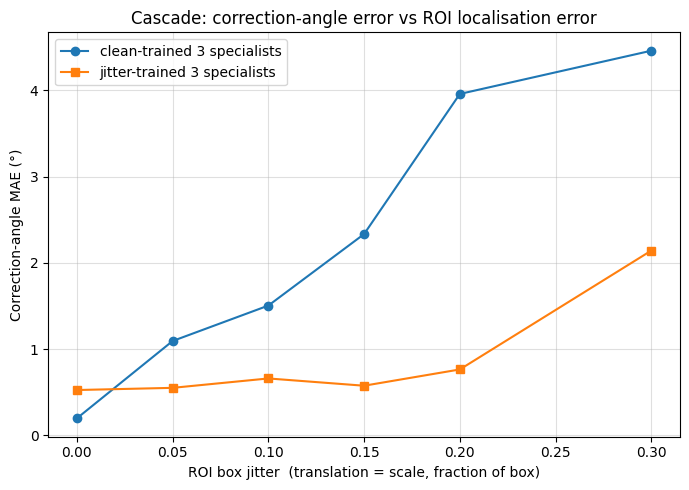

In [13]:
# Experiment 2 — cascade dose-response on the fixed 80/10/10 split.
# Train 3 specialists once clean and once with box-jitter, then sweep TEST-time box
# error and plot angle MAE vs jitter. The clean curve = naive cascade; the robust
# curve shows whether jitter-training flattens it. Level 0 = the oracle ceiling.
if RUN_SWEEP and samples_pool:
    tr_idx, va_idx, te_idx = split_indices(len(samples_pool))
    print(f"Fixed split: {len(tr_idx)} train / {len(va_idx)} val / {len(te_idx)} test imgs\n")
    print("Training clean-3 ...");  clean3  = train_specialists(samples_pool, tr_idx, va_idx, None,
                                                                ckpt_prefix="sweep_clean3")
    print("Training robust-3 ..."); robust3 = train_specialists(
        samples_pool, tr_idx, va_idx, {"trans": TRAIN_JITTER_LEVEL, "scale": TRAIN_JITTER_LEVEL},
        ckpt_prefix="sweep_robust3")

    curve = {"clean": [], "robust": []}
    for level in JITTER_SWEEP:
        fac  = oracle_box_factory if level == 0 else jitter_box_factory(level)
        nrep = 1 if level == 0 else N_REPEAT
        _, g,  p  = evaluate_crop_pipeline(samples_pool, te_idx, specialists_fn(clean3),
                                           fac, device, n_repeat=nrep, label=f"clean3@{level}",  show_reference=False)
        _, g2, p2 = evaluate_crop_pipeline(samples_pool, te_idx, specialists_fn(robust3),
                                           fac, device, n_repeat=nrep, label=f"robust3@{level}", show_reference=False)
        curve["clean"].append((level, _mae(g, p)))
        curve["robust"].append((level, _mae(g2, p2)))
        print(f"  jitter {level:.2f} | clean MAE {curve['clean'][-1][1]:.3f}\u00b0 | robust MAE {curve['robust'][-1][1]:.3f}\u00b0")
    RESULTS["curve"] = curve
    RESULTS["sweep_models"] = {"clean3": clean3, "robust3": robust3, "te_idx": te_idx}

    xs = [l for l, _ in curve["clean"]]
    plt.figure(figsize=(7, 5))
    plt.plot(xs, [m for _, m in curve["clean"]],  "o-", label="clean-trained 3 specialists")
    plt.plot(xs, [m for _, m in curve["robust"]], "s-", label="jitter-trained 3 specialists")
    if ONE_STAGE_CV:
        plt.axhline(ONE_STAGE_CV["mean"], color="k", ls="--", label="one-stage (your CV mean)")
    plt.xlabel("ROI box jitter  (translation = scale, fraction of box)")
    plt.ylabel("Correction-angle MAE (\u00b0)")
    plt.title("Cascade: correction-angle error vs ROI localisation error")
    plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()
else:
    print("RUN_SWEEP off (or empty pool) - skipped.")


## Experiment 3 · Robustness at a realistic box error (CV) — optional, heavy

The clean-vs-robust comparison at a single realistic jitter level, but with pooled-CV n rather than the single fixed split. Off by default (`RUN_ROBUST_CV`), since it retrains the 3-specialist arm five times per condition.


In [12]:
# Experiment 3 (optional, heavy) — robustness at one realistic jitter, via CV.
# Gives the clean-vs-robust comparison with proper n (pooled out-of-fold) at a
# single operating point, complementing the fixed-split curve above.
if RUN_ROBUST_CV and samples_pool:
    fac = jitter_box_factory(REALISTIC_JITTER)
    RESULTS["cv_jit_clean3"] = run_cv(
        samples_pool, "3", None, fac, n_repeat=N_REPEAT,
        label=f"CV jitter {REALISTIC_JITTER} | clean-train 3")
    RESULTS["cv_jit_robust3"] = run_cv(
        samples_pool, "3", {"trans": REALISTIC_JITTER, "scale": REALISTIC_JITTER}, fac,
        n_repeat=N_REPEAT, label=f"CV jitter {REALISTIC_JITTER} | robust-train 3")
else:
    print("RUN_ROBUST_CV off (or empty pool) - skipped.")



--- CV jitter 0.15 | clean-train 3 | fold 1/5 (43 tr / 11 va imgs) ---
  region 'femoral_head': 85 train / 22 val crops
    [CV_jitter_0.15__clean-train_3_f1/femoral_head] ep 0100/600 | train 0.00827 | val MSE 70510.21 px²
    [CV_jitter_0.15__clean-train_3_f1/femoral_head] ep 0200/600 | train 0.00207 | val MSE 171.37 px²
    [CV_jitter_0.15__clean-train_3_f1/femoral_head] ep 0300/600 | train 0.00072 | val MSE 48.49 px²
    [CV_jitter_0.15__clean-train_3_f1/femoral_head] ep 0400/600 | train 0.00044 | val MSE 34.26 px²
    [CV_jitter_0.15__clean-train_3_f1/femoral_head] ep 0500/600 | train 0.00033 | val MSE 37.23 px²
    [CV_jitter_0.15__clean-train_3_f1/femoral_head] ep 0600/600 | train 0.00031 | val MSE 44.79 px²
  region 'knee': 86 train / 22 val crops
    [CV_jitter_0.15__clean-train_3_f1/knee] ep 0100/600 | train 0.01087 | val MSE 19461.75 px²
    [CV_jitter_0.15__clean-train_3_f1/knee] ep 0200/600 | train 0.00192 | val MSE 1977.26 px²
    [CV_jitter_0.15__clean-train_3_f1/knee] e

## Experiment 4 · Real YOLO operating point — optional, experimental

Trains an actual detector on your COCO ROI boxes, predicts boxes on the test split, and feeds those *real* boxes into the stage-2 specialists — capturing the missed / duplicate / wrong-leg failures that jitter cannot. The result is one point to drop onto the cascade curve, plus a detection-failure (unscoreable-hemisphere) rate. Needs `ultralytics`; treat the cell as a template and verify against your data layout before trusting the number.


In [13]:
# Experiment 4 (OPTIONAL, EXPERIMENTAL — needs `ultralytics`, cannot be validated
# in this authoring environment, verify before trusting). Trains a real detector on
# your COCO ROI boxes (3 classes: femoral_head/knee/ankle), predicts boxes on the
# test split, assigns L/R by x like your dataset, then feeds those REAL boxes into
# the same stage-2 specialists. This captures the failures jitter cannot: missed,
# duplicate and wrong-leg detections. Drops the resulting point onto the cascade plot.
if RUN_YOLO and samples_pool:
    try:
        from ultralytics import YOLO
        import shutil, yaml

        _CLS = {1: 0, 2: 1, 3: 2}                       # COCO category_id -> YOLO class
        _CLS_REGION = {0: "femoral_head", 1: "knee", 2: "ankle"}
        coco = json.load(open(COCO_JSON_PATH))
        info = {im["id"]: im for im in coco.get("images", [])}
        anns = {}
        for a in coco.get("annotations", []):
            anns.setdefault(a.get("image_id"), []).append(a)
        by_name = {os.path.basename(im["file_name"]): iid for iid, im in info.items()}

        tr_idx, va_idx, te_idx = split_indices(len(samples_pool))
        root = os.path.abspath("yolo_ds")
        for sub in ("images/train", "images/val", "labels/train", "labels/val"):
            os.makedirs(os.path.join(root, sub), exist_ok=True)

        def _materialise(idxs, split):
            for si in idxs:
                p = samples_pool[si]["img_path"]; base = os.path.basename(p)
                iid = by_name.get(base)
                if iid is None or not os.path.exists(p):
                    continue
                W = float(info[iid].get("width", 1)); H = float(info[iid].get("height", 1))
                stem = os.path.splitext(base)[0]
                dst_img = os.path.join(root, f"images/{split}", base)
                if not os.path.exists(dst_img):
                    try: os.symlink(p, dst_img)
                    except Exception: shutil.copy(p, dst_img)
                rows = []
                for a in anns.get(iid, []):
                    c = _CLS.get(a.get("category_id")); bb = a.get("bbox")
                    if c is None or not bb or W <= 1 or H <= 1:
                        continue
                    x, y, w, h = bb
                    rows.append(f"{c} {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}")
                open(os.path.join(root, f"labels/{split}", stem + ".txt"), "w").write("\n".join(rows))

        _materialise(tr_idx, "train"); _materialise(va_idx, "val")
        yaml.safe_dump({"path": root, "train": "images/train", "val": "images/val",
                        "names": {0: "femoral_head", 1: "knee", 2: "ankle"}},
                       open(os.path.join(root, "hto.yaml"), "w"))

        det = YOLO("yolov8n.pt")
        det.train(data=os.path.join(root, "hto.yaml"), epochs=100, imgsz=1024,
                  batch=4, seed=SEED, verbose=False)

        pred_by_path = {}
        for si in te_idx:
            p = samples_pool[si]["img_path"]
            if not os.path.exists(p):
                continue
            res = det.predict(p, verbose=False)[0]
            Hh, Ww = res.orig_shape
            xyxy = res.boxes.xyxy.cpu().numpy(); cls = res.boxes.cls.cpu().numpy().astype(int)
            conf = res.boxes.conf.cpu().numpy()
            d = {}
            for c, region in _CLS_REGION.items():
                m = cls == c
                if not m.any():
                    continue
                boxes = xyxy[m]; cf = conf[m]
                order = cf.argsort()[::-1][:2]; boxes = boxes[order]
                cxs = [(b[0] + b[2]) / 2 for b in boxes]
                if len(boxes) == 2:
                    li, ri = (0, 1) if cxs[0] <= cxs[1] else (1, 0)
                    d[("L", region)] = tuple(boxes[li]); d[("R", region)] = tuple(boxes[ri])
                else:
                    side = "L" if cxs[0] < Ww / 2 else "R"
                    d[(side, region)] = tuple(boxes[0])
            pred_by_path[p] = d

        clean3 = RESULTS.get("sweep_models", {}).get("clean3")
        if clean3 is None:
            clean3 = train_specialists(samples_pool, tr_idx, va_idx, None, ckpt_prefix="yolo_clean3")
        fac = yolo_box_factory(pred_by_path)
        st, g, p, att, sc = evaluate_crop_pipeline(
            samples_pool, te_idx, specialists_fn(clean3), fac, device,
            label="YOLO detector | clean-3", count_failures=True)
        RESULTS["yolo"] = {"stats": st, "mae": _mae(g, p), "attempted": att, "scored": sc}
        print(f"\nYOLO operating point: MAE {RESULTS['yolo']['mae']:.3f}\u00b0 on {sc}/{att} scoreable hemispheres.")
    except ImportError:
        print("ultralytics not installed - `pip install ultralytics` to run the YOLO arm.")
    except Exception as ex:
        print(f"YOLO arm failed ({type(ex).__name__}: {ex}). It is a template - verify paths/labels.")
else:
    print("RUN_YOLO off (or empty pool) - skipped.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.4.80 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.53 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tf/notebooks/yolo_ds/hto.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, flipl

/usr/local/lib/python3.11/dist-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.11/dist-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic becaus

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3205.4±1745.0 MB/s, size: 7849.7 KB)
train: Scanning /tf/notebooks/yolo_ds/labels/train... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 223.9it/s 0.2s
train: New cache created: /tf/notebooks/yolo_ds/labels/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2513.4±1729.3 MB/s, size: 7895.5 KB)
val: Scanning /tf/notebooks/yolo_ds/labels/val... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 190.1it/s 0.0s
val: New cache created: /tf/notebooks/yolo_ds/labels/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to /tf/notebooks/runs/detect/train/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 8 dataloader workers
Logging resul

/usr/local/lib/python3.11/dist-packages/ultralytics/utils/loss.py:393: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      1/100      9.62G      2.898      5.113      2.233          3       1024: 100% ━━━━━━━━━━━━ 11/11 3.9it/s 2.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4s/it 1.4s
                   all          5         30          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

     98/100      9.62G     0.8514     0.8206     0.9201          3       1024: 100% ━━━━━━━━━━━━ 11/11 18.6it/s 0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 36.2it/s 0.0s
                   all          5         30      0.962          1      0.995       0.67

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.11/dist-packages/ultralytics/utils/loss.py:393: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


     99/100      9.62G     0.8356     0.8148      0.926          3       1024: 100% ━━━━━━━━━━━━ 11/11 20.3it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 35.4it/s 0.0s
                   all          5         30      0.962          1      0.995       0.67

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.11/dist-packages/ultralytics/utils/loss.py:393: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


    100/100      9.62G     0.8393     0.7803     0.9296          3       1024: 100% ━━━━━━━━━━━━ 11/11 19.6it/s 0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 34.3it/s 0.0s
                   all          5         30      0.963          1      0.995      0.666

100 epochs completed in 0.027 hours.
Optimizer stripped from /tf/notebooks/runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from /tf/notebooks/runs/detect/train/weights/best.pt, 6.3MB

Validating /tf/notebooks/runs/detect/train/weights/best.pt...
Ultralytics 8.4.53 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 37.6it/s 0.0s
                   all          5         30      0.968          1      0.995      0.716
Speed: 0.1ms prepro

## Summary · Collected results, cascade recap, headline comparison

One table across all conditions that ran, the cascade curve in numbers, the YOLO point if present, and the one-stage-vs-two-stage mean-MAE gap (a point estimate — for significance, log per-fold one-stage MAE and run a paired Wilcoxon against the matching fold here). Ends with a sanity overlay comparing predictions under oracle vs jittered ROIs on one test image.


In [14]:
# Experiment summary — collected table, cascade recap, and the headline comparison.
def _row(name, st):
    if not st:
        return f"{name:<40}{'(not run)':>10}"
    return (f"{name:<40}{st['n']:>6}{st['mean']:>9.3f}{st['median']:>9.3f}"
            f"{st['max']:>9.3f}{st['within_tol_pct']:>9.1f}{st['icc']:>8.3f}")

print("=" * 100)
print(f"{'Condition':<40}{'n':>6}{'mean':>9}{'median':>9}{'max':>9}{'within%':>9}{'ICC':>8}   (deg)")
print("=" * 100)
if ONE_STAGE_CV:
    print(_row("one-stage  (your CV, pasted)", ONE_STAGE_CV))
for key, name in [("cv_oracle_3",  "two-stage  oracle | 3 specialists"),
                  ("cv_oracle_1",  "two-stage  oracle | 1 shared"),
                  ("cv_jit_clean3", f"two-stage  jitter {REALISTIC_JITTER} | clean-train 3"),
                  ("cv_jit_robust3", f"two-stage  jitter {REALISTIC_JITTER} | robust-train 3")]:
    if key in RESULTS:
        print(_row(name, RESULTS[key]["stats"]))
print("=" * 100)

if "curve" in RESULTS:
    print("\nCascade curve (fixed-split test MAE, deg):")
    for (lv, mc), (_, mr) in zip(RESULTS["curve"]["clean"], RESULTS["curve"]["robust"]):
        print(f"  jitter {lv:.2f} |  clean {mc:.3f}   robust {mr:.3f}")
if "yolo" in RESULTS and RESULTS["yolo"]["stats"]:
    y = RESULTS["yolo"]
    print(f"\nReal YOLO operating point:  MAE {y['mae']:.3f} deg  "
          f"({y['scored']}/{y['attempted']} hemispheres scoreable; "
          f"{y['attempted']-y['scored']} lost to detection failures).")

# headline gap (point estimate; for significance log per-fold one-stage MAE and pair)
if ONE_STAGE_CV and RESULTS.get("cv_oracle_3", {}).get("stats"):
    gap = RESULTS["cv_oracle_3"]["stats"]["mean"] - ONE_STAGE_CV["mean"]
    print(f"\nOne-stage vs two-stage(oracle, 3 specialists) mean-MAE gap: {gap:+.3f} deg "
          f"-> {'one-stage better' if gap > 0 else 'two-stage better'} even at the perfect-ROI ceiling.")
    print("For a real paired test, record per-fold one-stage MAE in the one-stage notebook "
          "and run Wilcoxon against the matching fold's two-stage MAE here.")

# optional sanity overlay (oracle vs a jitter level) on one test image
if RESULTS.get("sweep_models"):
    sm = RESULTS["sweep_models"]; te_idx = sm["te_idx"]
    chosen = next((si for si in te_idx
                   if all(samples_pool[si]["keypoints"][(HEMI_BASE[s] + o) * 3 + 2] > 0
                          for s in ("L", "R") for o in range(6))), te_idx[0] if te_idx else None)
    if chosen is not None:
        s = samples_pool[chosen]; img = Image.open(s["img_path"]).convert("RGB"); kf = s["keypoints"]
        fig, axes = plt.subplots(1, 2, figsize=(12, 13))
        for ax, (lab, fac) in zip(axes, [("oracle box", oracle_box_factory),
                                         (f"jitter {REALISTIC_JITTER}", jitter_box_factory(REALISTIC_JITTER))]):
            ax.imshow(img, cmap="gray"); box_fn = fac(SEED)
            for side in ("L", "R"):
                base = HEMI_BASE[side]
                gt = {n: np.array([kf[(base + o) * 3], kf[(base + o) * 3 + 1]])
                      for o, n in enumerate(_SIDE_KEYS) if kf[(base + o) * 3 + 2] > 0}
                if len(gt) < 6:
                    continue
                pr = {}
                for region in REGION_ORDER:
                    m, layout, _ = specialists_fn(sm["clean3"])(region)
                    pr.update(predict_region(img, box_fn(s, side, region), side, region,
                                             m, layout, REGIONS[region], device))
                if len(pr) < 6:
                    continue
                ga, *_ = evaluate_side_geometry(gt); pa, *_ = evaluate_side_geometry(pr)
                for n in _SIDE_KEYS:
                    ax.scatter(*gt[n], c="lime", s=18, zorder=5)
                    ax.scatter(*pr[n], c="red", s=18, marker="x", zorder=6)
                ax.text(pr["ost_point"][0], pr["ost_point"][1],
                        f" {side}: GT {ga:.1f}\u00b0 / pred {pa:.1f}\u00b0",
                        color="white", fontsize=10, weight="bold")
            ax.set_title(f"clean-3 stage-2, {lab}"); ax.axis("off")
        plt.suptitle("GT (green) vs prediction (red x): oracle vs jittered ROI", fontsize=13)
        plt.tight_layout(); plt.show()


Condition                                    n     mean   median      max  within%     ICC   (deg)
two-stage  jitter 0.15 | clean-train 3     321    2.263    1.152   17.826     62.0   0.722
two-stage  jitter 0.15 | robust-train 3    321    0.745    0.380   11.558     87.5   0.953

Real YOLO operating point:  MAE 2.530 deg  (11/12 hemispheres scoreable; 1 lost to detection failures).
